# Principal Component Analysis with Cancer Data

In [276]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [277]:
data = pd.read_csv('breast-cancer-wisconsin-data.csv')
data.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [278]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [279]:
data.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [280]:
data.dtypes

ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [281]:
data.shape

(699, 11)

In [282]:
data.describe(include='all')

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699,699.000000,699.000000,699.000000,699.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,402,NaN,NaN,NaN,NaN
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,NaN,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,NaN,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,NaN,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,NaN,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,NaN,5.000000,4.000000,1.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [283]:
pd.isna(data).count()

ID                             699
ClumpThickness                 699
Cell Size                      699
Cell Shape                     699
Marginal Adhesion              699
Single Epithelial Cell Size    699
Bare Nuclei                    699
Normal Nucleoli                699
Bland Chromatin                699
Mitoses                        699
Class                          699
dtype: int64

In [285]:
# No missing values found. So let us try to remove ? from bare nuclei column
data['Bare Nuclei'].value_counts()
# Get count of rows having ?

1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: Bare Nuclei, dtype: int64

In [288]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [289]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [290]:
df = data.loc[data['Bare Nuclei'] != '?',:]

In [291]:
df.shape

(683, 11)

In [293]:
df['Bare Nuclei'].value_counts()

1     402
10    132
2      30
5      30
3      28
8      21
4      19
9       9
7       8
6       4
Name: Bare Nuclei, dtype: int64

In [294]:
df = df.drop_duplicates()

In [295]:
#there are 9 duplicates, hence those values are been dropped.

In [296]:
df.shape

(675, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


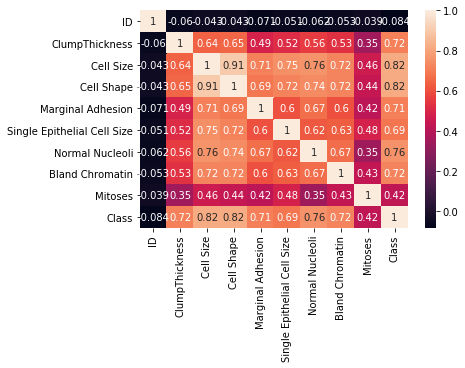

In [297]:
# Check for correlation of variable
corr= df.corr()
sns.heatmap(corr,annot=True)

In [298]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

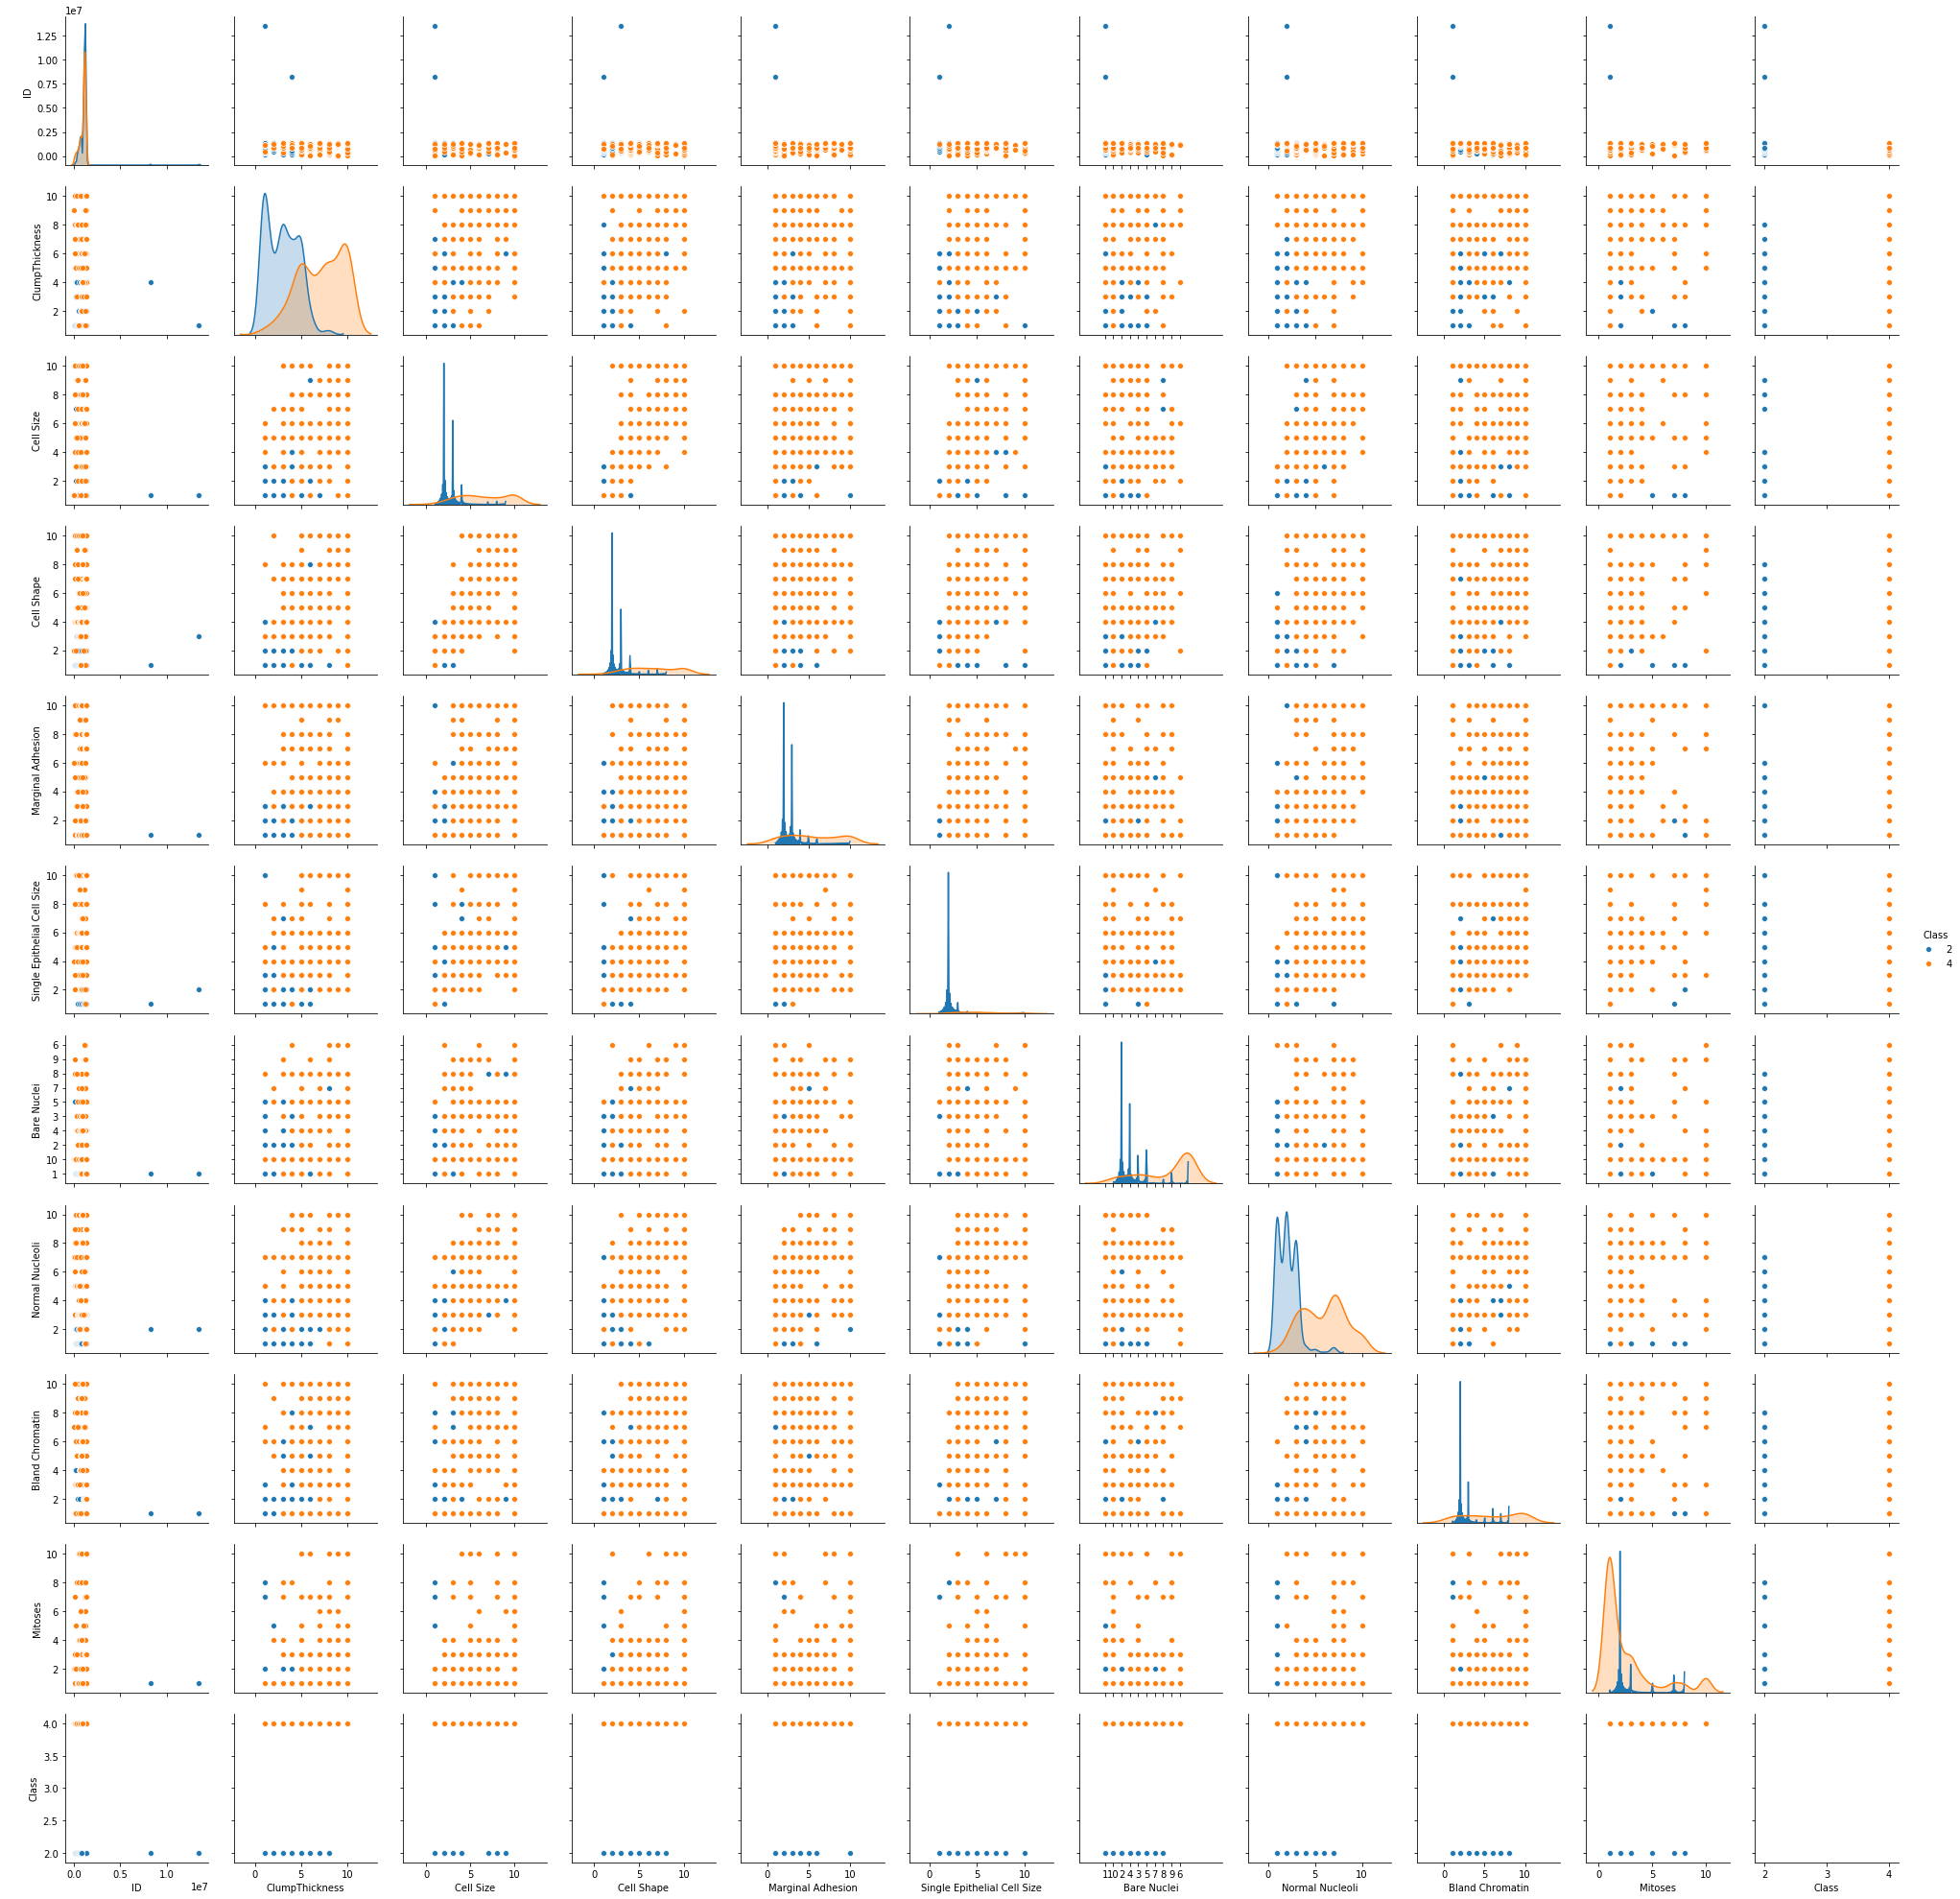

In [299]:
#Let us check for pair plots
sns.pairplot(df,diag_kind='kde',hue='Class')

Class
2    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
4    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
dtype: object

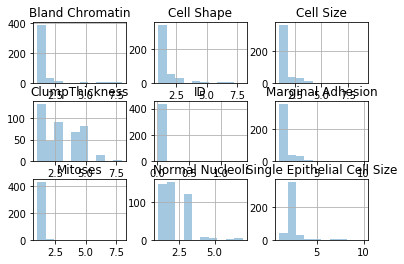

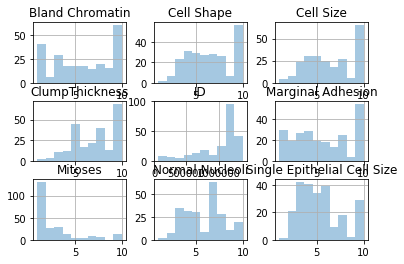

In [300]:
#Bivariate Analysis
df.groupby('Class').hist(alpha=0.4)

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [301]:
# We could see most of the outliers are now removed.
# drop ID and Class columns
X = df.drop(['ID','Class'],axis=1)
y = df['Class']

In [302]:
X.shape

(675, 9)

In [303]:
#Outliers
#the data is ordinal and the maximum value is 10.
#Even if we remove the outlier we are end up losing 20% of data(approx 200 rows)
#The outlier in one feature represents one of the class, hence we see peaks in the pair plot of one class while other class
#has skewed data.
#Hence there are no Outliers in the data.

In [304]:
#Standard Scalar
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
pd.DataFrame(X_std).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
0,675.0,6.398174e-17,1.000742,-1.224595,-0.869831,-0.160301,0.549228,1.968288
1,675.0,4.473788e-17,1.000742,-0.703193,-0.703193,-0.703193,0.607105,2.244977
2,675.0,-3.019807e-16,1.000742,-0.742647,-0.742647,-0.742647,0.602186,2.283228
3,675.0,-2.450715e-16,1.000742,-0.643363,-0.643363,-0.643363,0.400556,2.488394
4,675.0,4.079864e-16,1.000742,-1.010317,-0.557185,-0.557185,0.349080,3.067874
5,675.0,-6.919568e-16,1.000742,-0.698117,-0.698117,-0.698117,0.677332,1.777692
6,675.0,2.644798e-16,1.000742,-0.996284,-0.588466,-0.180648,0.634987,2.674077
7,675.0,-4.437603e-16,1.000742,-0.615645,-0.615645,-0.615645,0.363680,2.322329
8,675.0,-4.743531e-16,1.000742,-0.349142,-0.349142,-0.349142,-0.349142,4.824116


# Q6 Create a covariance matrix for identifying Principal components

In [305]:
# PCA
# Step 1 - Create covariance matrix

cov_matrix = np.cov(X_std.T)

print('Covariance Matrix \n%s', cov_matrix)


Covariance Matrix 
%s [[1.00148368 0.64179757 0.6535854  0.49014737 0.51994192 0.59481694
  0.55722956 0.53468337 0.35179132]
 [0.64179757 1.00148368 0.9070993  0.71571019 0.7499397  0.69091892
  0.76054465 0.72478554 0.46287028]
 [0.6535854  0.9070993  1.00148368 0.69505865 0.71825054 0.71193067
  0.73896771 0.72431427 0.44367028]
 [0.49014737 0.71571019 0.69505865 1.00148368 0.60437455 0.67743141
  0.67274039 0.60308103 0.41901379]
 [0.51994192 0.7499397  0.71825054 0.60437455 1.00148368 0.58361701
  0.62357253 0.6350697  0.4849303 ]
 [0.59481694 0.69091892 0.71193067 0.67743141 0.58361701 1.00148368
  0.68014431 0.58882248 0.34029648]
 [0.55722956 0.76054465 0.73896771 0.67274039 0.62357253 0.68014431
  1.00148368 0.66981274 0.34619368]
 [0.53468337 0.72478554 0.72431427 0.60308103 0.6350697  0.58882248
  0.66981274 1.00148368 0.43368123]
 [0.35179132 0.46287028 0.44367028 0.41901379 0.4849303  0.34029648
  0.34619368 0.43368123 1.00148368]]


# Q7 Identify eigen values and eigen vector

In [306]:
# Step 2- Get eigen values and eigen vector
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.30129202  0.14382106 -0.87456587 -0.00397982 -0.0422162   0.01765212
  -0.27456474 -0.17685689  0.12206293]
 [-0.38047894  0.04530412  0.03820758 -0.73413297  0.187475   -0.1383224
   0.43174719 -0.26065752 -0.06437646]
 [-0.37721535  0.08032574 -0.01879307  0.66652232  0.1647692  -0.09050931
   0.58175214 -0.18009963 -0.02095043]
 [-0.33424356  0.05792885  0.38087816  0.04499803 -0.51017646 -0.02771199
  -0.24523402 -0.44650274  0.46613314]
 [-0.33574224 -0.17428826  0.13741306  0.06555505  0.37847261 -0.68074099
  -0.39574476  0.25535452  0.07246576]
 [-0.33444941  0.26083232 -0.02540712 -0.07399867 -0.51594288 -0.04672706
   0.18973227  0.71329136 -0.02872983]
 [-0.34620359  0.22791437  0.19876053  0.06603364  0.00423114  0.23600622
  -0.3625948  -0.14732488 -0.75857463]
 [-0.336225   -0.02954431  0.1366274  -0.02359043  0.45074714  0.65585696
  -0.11078206  0.26956903  0.38548003]
 [-0.23014187 -0.90345301 -0.10272634  0.00811798 -0.25102302  0.14197332
   0.

In [307]:
print("Eigen Values:")
pd.DataFrame(eig_vals).transpose()

Eigen Values:


,0,1,2,3,4,5,6,7,8
0,5.919353,0.778109,0.540765,0.089974,0.459055,0.371367,0.261931,0.300533,0.292266


# Q8 Find variance and cumulative variance by each eigen vector

In [308]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 65.67315367  74.30600209  80.30560198  85.39865182  89.51884018
  92.85315285  96.09574601  99.00177425 100.        ]


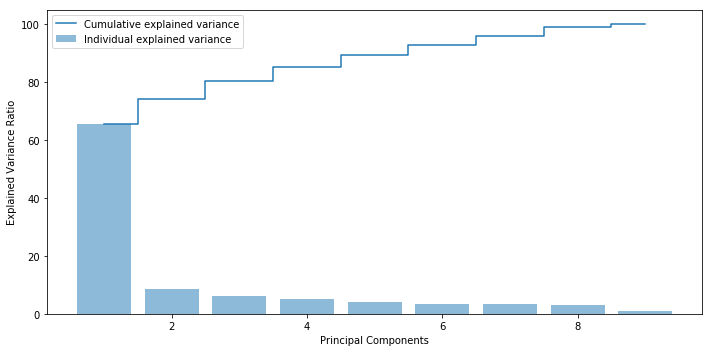

In [309]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [310]:
from sklearn.decomposition import PCA
pca = PCA(n_components=9)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=9, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [311]:
x_transformed = pd.DataFrame(pca.transform(X_std))
x_transformed.shape

(675, 9)

In [312]:
x_transformed.columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9']
x_transformed.describe()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
count,6.750000e+02,6.750000e+02,6.750000e+02,6.750000e+02,6.750000e+02,6.750000e+02,6.750000e+02,6.750000e+02,6.750000e+02
mean,1.888202e-16,1.733593e-16,9.539694e-18,-3.980355e-17,7.014965e-17,1.809252e-17,8.158083e-17,-1.776357e-17,3.955684e-17
std,2.432972e+00,8.821049e-01,7.353673e-01,6.775357e-01,6.093990e-01,5.482092e-01,5.406167e-01,5.117915e-01,2.999560e-01
min,-2.336644e+00,-2.089014e+00,-2.396996e+00,-2.679273e+00,-1.843072e+00,-2.481791e+00,-1.956812e+00,-2.030179e+00,-1.396929e+00
25%,-1.829545e+00,-2.571503e-01,-4.678029e-01,-1.703510e-01,-2.177971e-01,-2.156439e-01,-2.819251e-01,-2.346679e-01,-7.697205e-02
50%,-1.471199e+00,3.731381e-02,-2.754866e-02,5.273847e-02,7.084906e-03,-3.015685e-02,6.325529e-03,-4.876411e-03,1.764141e-02
75%,2.016135e+00,1.812840e-01,5.110160e-01,1.530731e-01,1.242794e-01,1.527963e-01,3.156858e-01,2.558891e-01,4.880681e-02
max,7.014682e+00,4.708945e+00,2.621639e+00,2.830223e+00,2.762529e+00,2.533376e+00,2.028735e+00,2.103807e+00,1.709886e+00


# Q10 Find correlation between components and features

In [313]:
final_data = pd.concat([df,x_transformed],axis=1)
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 698 entries, 0 to 698
Data columns (total 20 columns):
ID                             675 non-null float64
ClumpThickness                 675 non-null float64
Cell Size                      675 non-null float64
Cell Shape                     675 non-null float64
Marginal Adhesion              675 non-null float64
Single Epithelial Cell Size    675 non-null float64
Bare Nuclei                    675 non-null object
Normal Nucleoli                675 non-null float64
Bland Chromatin                675 non-null float64
Mitoses                        675 non-null float64
Class                          675 non-null float64
PC1                            675 non-null float64
PC2                            675 non-null float64
PC3                            675 non-null float64
PC4                            675 non-null float64
PC5                            675 non-null float64
PC6                            675 non-null float64
PC7         

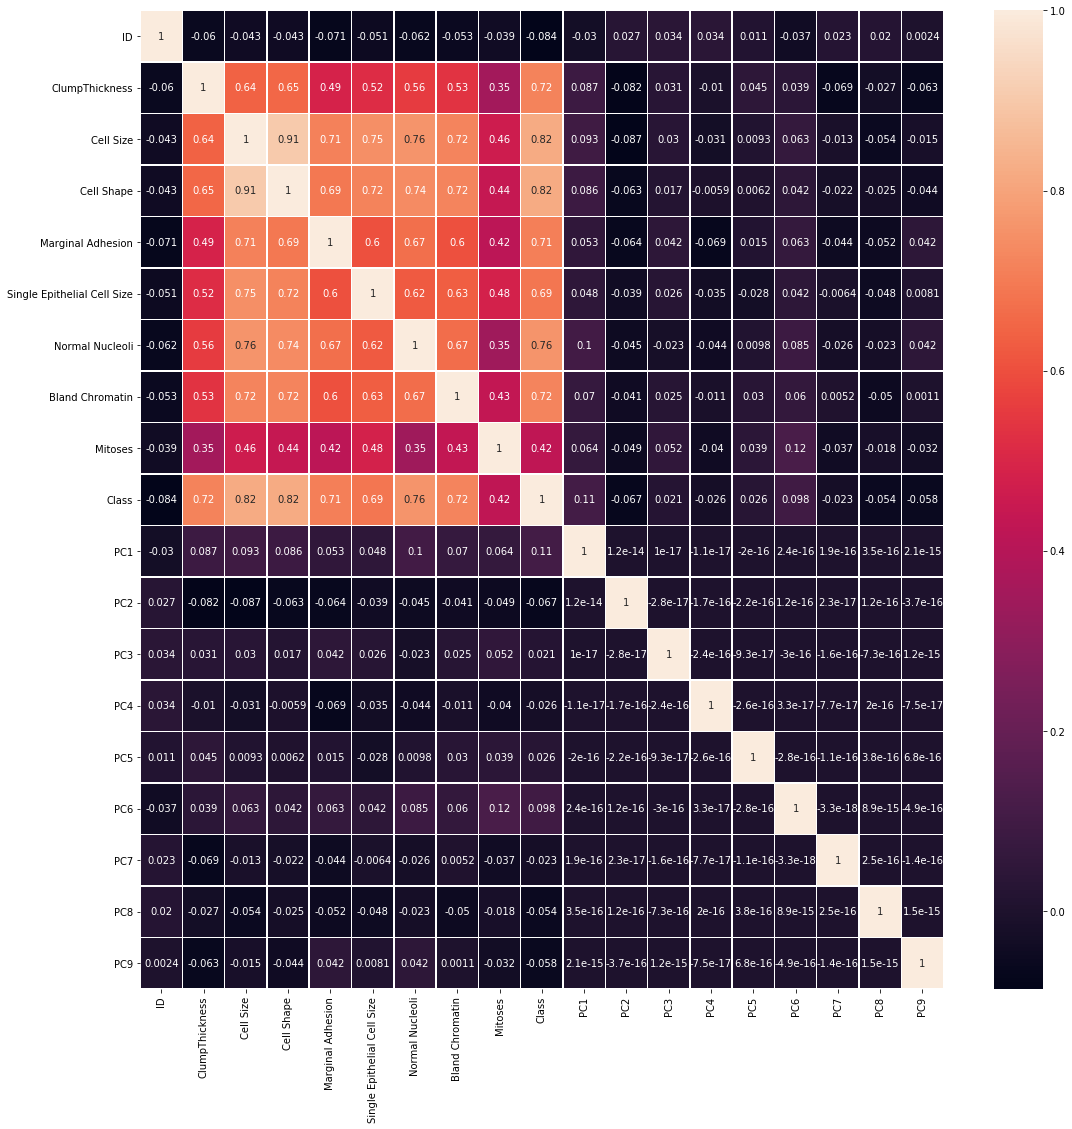

In [314]:
corr1 = final_data.corr()
fig, ax = plt.subplots(figsize=(18,18))
sns.heatmap(corr1,annot=True,linewidths=0.5,ax=ax)

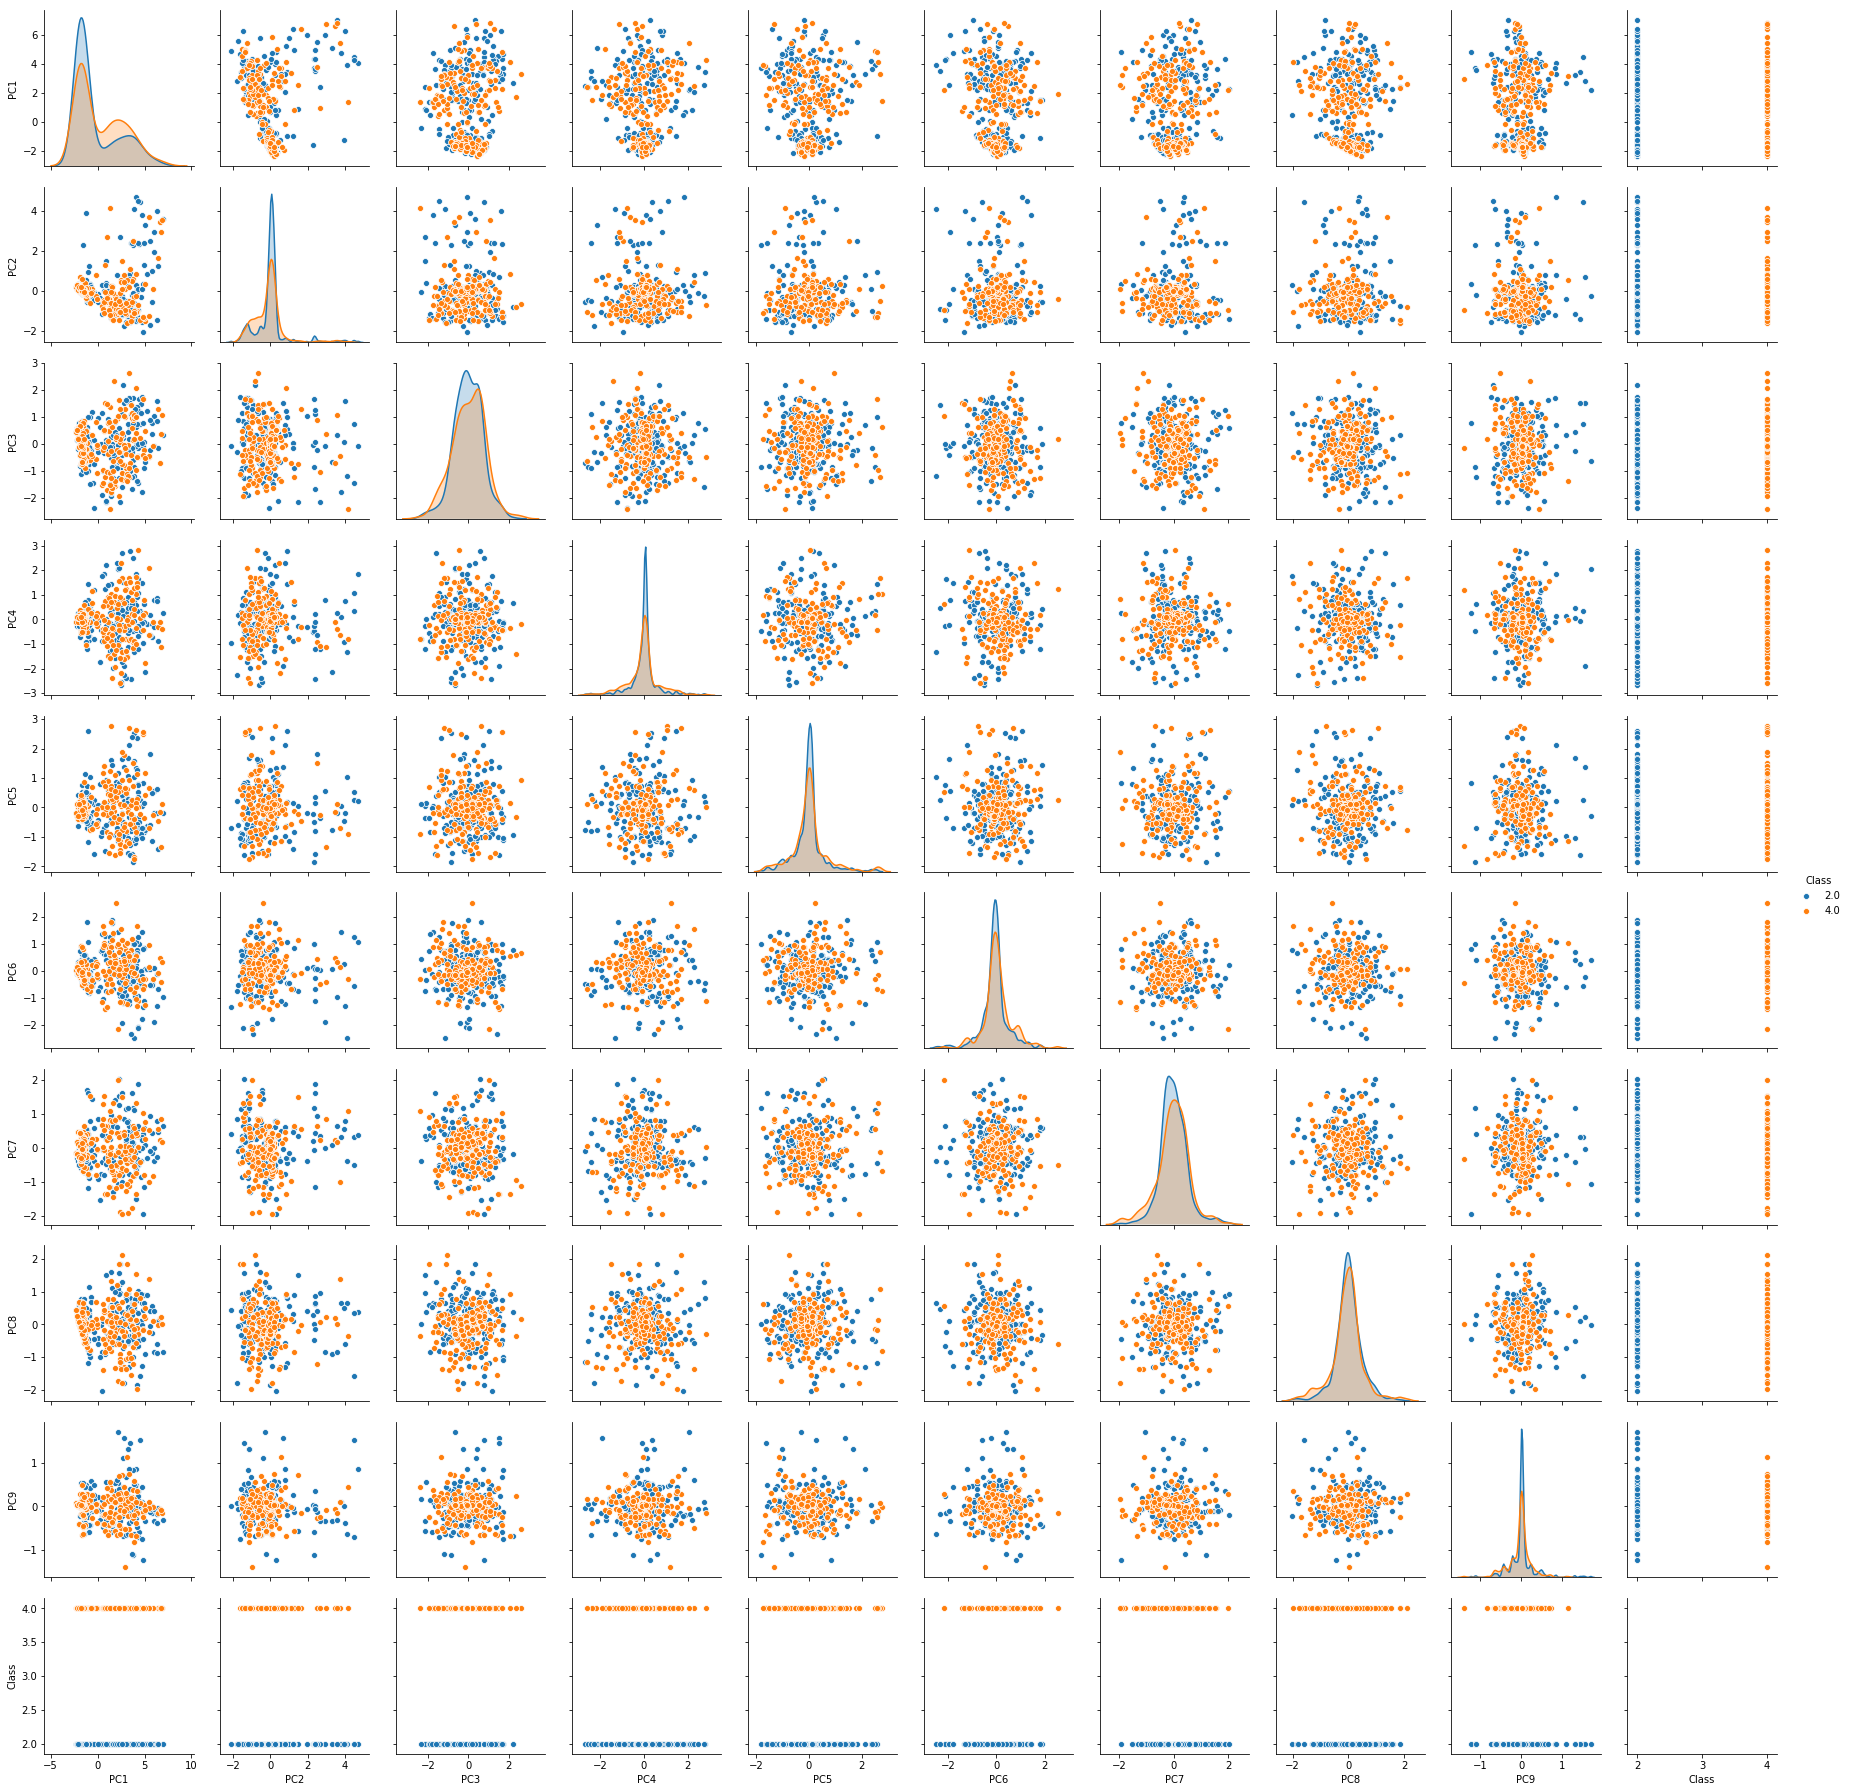

In [315]:
#Let us check pairplot on the pca dimensions

Proj_data_df = x_transformed.join(y)

sns.pairplot(Proj_data_df, diag_kind='kde',hue='Class') 

In [316]:
#We can see the peaks are smooth in the above pairplot for the PC dimensions compared to the older features.